In [ ]:
len(df_ops['op_id'].unique()) # starting

# Total operations recorded: 130,960

130960

In [ ]:
# df_preop = df_preop.dropna(subset="opend_time")
# df_preop = df_preop.dropna(subset="opstart_time")

len(df_preop['op_id'].unique())
# Exclusion of operations with unrecorded start or end time: 127,342

127342

In [ ]:
# df_preop = df_preop[~(df_preop['weight'].isna() | df_preop['height'].isna())]

len(df_preop['op_id'].unique())
# Exclusion of operations with unrecorded height or weight: 125,577

125577

In [ ]:
# df_ops = df_ops.drop(df_ops[df_ops['antype'] == 'Regional'].index)

len(df_preop['op_id'].unique())
# Exclusion of operations with Regional antype: 125,420

125420

In [ ]:
# prefixes_to_exclude = ["10", "0TY", "B50", "B51"]

len(df_preop['op_id'].unique())
# Exclusion of operations with prefixes "10", "0TY", "B50", "B51": 122,586

122586

In [ ]:
len(df['op_id'].unique()) #from the intraop merge
# Exclusion of operations without recorded intraoperative variables: 122,558

122558

In [ ]:
# df_preop = df_preop[df_preop['preop_creatinine'].notna()]

len(df_preop['op_id'].unique())
# Exclusion of operations : 120,772

120772

In [ ]:
# # Cuts samples down to almost half because insufficient data
# df_creatinine = df_labs[df_labs['item_name'] == 'creatinine']
# df_merge = pd.merge(df_preop, df_creatinine, on='subject_id')
# df_merge_filtered = df_merge[
#     (df_merge['chart_time'] > df_merge['opend_time']) &
#     (df_merge['chart_time'] < (df_merge['opend_time'] + 2*24*60))
# ]

len(df_merge_filtered['op_id'].unique())

58378

In [6]:
# df_aki = df_aki[df_aki["preop_creatinine"] <= 4.5]

len(df_aki['op_id'].unique())

57724

In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter
from sklearn.preprocessing import StandardScaler
import torch
import random
from torch.nn.utils.rnn import pack_padded_sequence
import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [1]:
import numpy as np
import pandas as pd
tabular_csv = '/home/server/Projects/data/AKI/tabular_combined.csv'
df_tabular = pd.read_csv(tabular_csv)


In [ ]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter
from sklearn.preprocessing import StandardScaler
import torch
import random
from torch.nn.utils.rnn import pack_padded_sequence
import torch
import torch.nn as nn
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

tabular_csv = '/home/server/Projects/data/AKI/tabular_combined.csv'
df_tabular = pd.read_csv(tabular_csv)

file = '/home/server/Projects/data/AKI/time_series_cleaned.csv'
df_time = pd.read_csv(file)

# drops operations that are missing over half of all features
feature_mask = df_time.drop(columns=['op_id', 'chart_time']).notna().astype(int)
df_time['presence'] = feature_mask.sum(axis=1) / 24
# drops about 1/6 data
df_time = df_time[df_time['presence'] > (1/2)].drop(columns=['presence']) 
mask_flag_value = 0
df_time = df_time.fillna(mask_flag_value)
bool_cols = df_tabular.select_dtypes(include='bool').columns
df_tabular[bool_cols] = df_tabular[bool_cols].astype(float)


# pivot and pad, re-df
padded_tensors = []
pad_length = 200
op_ids = []
sequence_lengths = []
for op_id, group in tqdm(df_time.groupby("op_id"), desc="grouping by op_ids"):
    mat = torch.tensor(group.drop(columns=['op_id', 'chart_time']).values)
    if mat.shape[0] < 200: # throws away about 4% of longest operations bc they would extend max pad length from 200 to like 600
        padded_tensors.append(torch.nn.functional.pad(mat, pad=(0, 0, 0, pad_length - mat.shape[0]), value=0))
        op_ids.append(op_id)
        sequence_lengths.append(mat.shape[0])
df_time = pd.DataFrame({
    'op_id': op_ids,
    'time_tensors': padded_tensors,
    'seq_len': sequence_lengths
    })
df_combined = df_time.merge(df_tabular, on='op_id', how='inner')

# shuffle, and then set aside first fifth for test
df_combined = df_combined.sample(frac=1, random_state=42).reset_index(drop=True)
test_idx_start = 0
test_idx_end = len(df_combined) // 10
df_test = df_combined.iloc[test_idx_start : test_idx_end]
df_train = df_combined.iloc[test_idx_end :]

# upsample the minority class to approximately match the count of the majority class
df_train_majority = df_train[df_train['aki'] < 0.3]
df_train_minority = df_train[df_train['aki'] >= 0.3]
majority_count = df_train_majority.shape[0]
minority_count = df_train_minority.shape[0]
upsample_ratio = 2 * majority_count // minority_count
df_train_minority = pd.concat([df_train_minority] * upsample_ratio, ignore_index=True)
df_train = pd.concat([df_train_minority, df_train_majority], ignore_index=True)
df_train = df_train.sample(frac=1, random_state=42).reset_index(drop=True) #reshuffle
df_train_file = '/home/server/Projects/data/AKI/lstm/df_train.pkl'
df_test_file = '/home/server/Projects/data/AKI/lstm/df_test.pkl'
df_train.to_pickle(df_train_file)
df_test.to_pickle(df_test_file)

grouping by op_ids: 100%|██████████| 48956/48956 [00:17<00:00, 2783.15it/s]


In [ ]:
df_train_file = '/home/server/Projects/data/AKI/lstm/df_train.pkl'
df_test_file = '/home/server/Projects/data/AKI/lstm/df_test.pkl'
df_train = pd.read_pickle(df_train_file)
df_test

In [7]:
def df_to_tensors(df):

    remove_cols = [col for col in df.columns if '_isna' in col]
    remove_cols += ['op_id', 'time_tensors', 'seq_len', 'aki', 'aki_boolean', 'aki_positive']
    X_tab = torch.tensor(df.drop(columns=remove_cols).values).float()
    X_time = torch.stack(df['time_tensors'].tolist()).float()
    y = torch.tensor(df['aki'].values).unsqueeze(1).float()
    sequence_lengths = df['seq_len'].tolist()
    return X_tab, X_time, y, sequence_lengths


In [3]:
def set_seed(seed=42):
    random.seed(seed)                           # Python random module
    np.random.seed(seed)                        # NumPy
    torch.manual_seed(seed)                     # PyTorch CPU
    torch.cuda.manual_seed(seed)                # PyTorch GPU
    torch.cuda.manual_seed_all(seed)            # For multi-GPU setups
    torch.backends.cudnn.deterministic = True   # Makes cuDNN deterministic
    torch.backends.cudnn.benchmark = False      # Avoids dynamic optimizations



class HybridLSTM(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, tabular_input_size):
        super(HybridLSTM, self).__init__()
        self.num_classes = num_classes #number of classes
        self.num_layers = num_layers #number of layers
        self.input_size = input_size #input size
        self.hidden_size = hidden_size #hidden state
        self.tabular_input_size = tabular_input_size

        self.mlp = nn.Sequential(
           nn.Linear(tabular_input_size, 64),
           nn.ReLU(),
           nn.Linear(64, 32),
           nn.ReLU()
        )

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True) #lstm
        self.fc0 =  nn.Linear(hidden_size + 32, 128) #fully connected 1
        self.fc = nn.Linear(128, num_classes) #fully connected last layer


        self.relu = torch.tanh #lol
    # def _init_weights(self):
    #     for name, param in self.lstm.named_parameters():
    #         if 'weight' in name:
    #             nn.init.xavier_uniform_(param)  # Use Xavier initialization
    #         elif 'bias' in name:
    #             nn.init.constant_(param, 0)
    
    def forward(self,tab_x, seq_x, seq_len):
        # h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #hidden state
        # c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #internal state
        # Propagate input through LSTM
        packed_input = pack_padded_sequence(seq_x, seq_len, batch_first=True, enforce_sorted=False)
        output, (hn, cn) = self.lstm(packed_input)#, (h_0, c_0)) #lstm with input, hidden, and internal state
        hn = hn.view(-1, self.hidden_size) #reshaping the data for Dense layer next
        lstm_out = self.relu(hn)
        mlp_out = self.mlp(tab_x)

        out = torch.cat((lstm_out, mlp_out), dim=1)
        
        out = self.fc0(out) #first Dense
        out = self.relu(out) #relu
        out = self.fc(out) #Final Output
        return out

In [5]:
X_tab_train, X_time_train, y_train, seq_len_train = df_to_tensors(df_train)
X_tab_train = X_tab_train.to(device)
X_time_train = X_time_train.to(device)
y_train = y_train.to(device)

In [6]:


# extra_string = 'hybrid_hs32'
# writer = SummaryWriter('/home/server/Projects/data/AKI/runs/hybridlstm_' + datetime.now().strftime("%D:%H:%M:%S") + extra_string)

num_epochs = 1000 #1000 epochs
learning_rate = 0.001 #0.001 lr

tabular_input_size = X_tab_train.shape[1] #271 without isna
input_size = 24 #number of features
hidden_size = 2 * 16 #number of features in hidden state
num_layers = 1 #number of stacked lstm layers

num_classes = 1 #number of output classes 

batch_size = 5000
num_train_samples = X_tab_train.shape[0]
num_batches = int(np.ceil(num_train_samples / batch_size))


set_seed(42)

lstm1 = HybridLSTM(num_classes, input_size, hidden_size, num_layers, tabular_input_size).to(device)

In [7]:
criterion = torch.nn.MSELoss()    # mean-squared error for regression
optimizer = torch.optim.Adam(lstm1.parameters(), lr=learning_rate) 
for epoch in tqdm(range(num_epochs)):
  batch_loss = 0
  for i in range(num_batches):
    beginning_idx = i * batch_size
    ending_idx = min(num_train_samples, (i + 1) * batch_size)
    X_time = X_time_train[beginning_idx: ending_idx]
    X_tab = X_tab_train[beginning_idx: ending_idx]
    y = y_train[beginning_idx: ending_idx]
    seq_len = seq_len_train[beginning_idx: ending_idx]
    outputs = lstm1.forward(X_tab, X_time, seq_len) #forward pass
    
    optimizer.zero_grad() #calculate the gradient, manually setting to 0
    loss = criterion(outputs, y)
    loss.backward() #calculates the loss of the loss function
    optimizer.step() #improve from loss, i.e backprop
    batch_loss += loss.item()

  if epoch % 10 == 0:
    print("Epoch: %d, loss: %1.5f" % (epoch, batch_loss / num_batches))
    # writer.add_scalar('training loss',
    #                       batch_loss / num_batches,
    #                       epoch * num_batches + i)
print("----------")

  0%|          | 1/1000 [00:01<30:12,  1.81s/it]

Epoch: 0, loss: 0.45125


  1%|          | 11/1000 [00:14<20:58,  1.27s/it]

Epoch: 10, loss: 0.02522


  2%|▏         | 21/1000 [00:27<20:46,  1.27s/it]

...

Epoch: 980, loss: 0.00202


 99%|█████████▉| 991/1000 [21:16<00:11,  1.30s/it]

Epoch: 990, loss: 0.00165


100%|██████████| 1000/1000 [21:27<00:00,  1.29s/it]

----------


In [21]:
lstm_model = '/home/server/Projects/data/AKI/lstm/lstm_hybrid_model.pth'
torch.save(lstm1, lstm_model)

In [5]:
lstm_model = '/home/server/Projects/data/AKI/lstm/lstm_hybrid_model.pth'

lstm1 = torch.load(lstm_model)

/tmp/ipykernel_341660/690982723.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  lstm1 = torch.load(lstm_model)


In [8]:
X_tab_test, X_time_test, y_test, seq_len_test = df_to_tensors(df_test)
X_tab_test = X_tab_test.to(device)
X_time_test = X_time_test.to(device)
y_test = y_test.to(device)

In [9]:
outputs = lstm1(X_tab_test, X_time_test, seq_len_test)

In [10]:
leg_y_test = (y_test > 0.3).T.tolist()[0]
leg_y_pred = (outputs > 0.3).T.tolist()[0]

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
print(classification_report(leg_y_test, leg_y_pred))

              precision    recall  f1-score   support

       False       0.95      0.92      0.94      8944
        True       0.23      0.33      0.27       630

    accuracy                           0.89      9574
   macro avg       0.59      0.63      0.61      9574
weighted avg       0.90      0.89      0.89      9574



In [ ]:
fpr, tpr, thresholds = roc_curve((y_test > 0.3).T.tolist()[0],  (outputs_prob).T.tolist()[0])
rc_auc = auc(fpr, tpr)

In [8]:

import pickle
seq_len_file = '/home/server/Projects/data/AKI/lstm/seq_len.pt'

with open(seq_len_file, "rb") as fp:   
    sequence_lengths = pickle.load(fp)

X_tab_tot_file = '/home/server/Projects/data/AKI/lstm/X_tab.pt'
X_time_tot_file = '/home/server/Projects/data/AKI/lstm/X_time.pt'
y_tot_file = '/home/server/Projects/data/AKI/lstm/y.pt'
X_tab_tot = torch.load(X_tab_tot_file)
X_time_tot = torch.load(X_time_tot_file)
y_tot = torch.load(y_tot_file)

num_samples_tot = len(sequence_lengths)
split_idx = num_samples_tot // 5

X_time_train = X_time_tot[split_idx:, :, :].to(device)
X_tab_train = X_tab_tot[split_idx:, :].to(device)
y_train = y_tot[split_idx:].unsqueeze(1).to(device)
seq_len_train = sequence_lengths[split_idx:]

/tmp/ipykernel_339639/2023492753.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  X_tab_tot = torch.load(X_tab_tot_file)
/tmp/ipykernel_339639/2023492753.py:11: FutureWa

In [ ]:
combined_no_aki
combined_aki


In [ ]:

# import pickle
# seq_len_file = '/home/server/Projects/data/AKI/lstm/seq_len.pt'

# with open(seq_len_file, "wb") as fp:
#     pickle.dump(sequence_lengths, fp)

# X_tab_tot_file = '/home/server/Projects/data/AKI/lstm/X_tab.pt'
# X_time_tot_file = '/home/server/Projects/data/AKI/lstm/X_time.pt'
# y_tot_file = '/home/server/Projects/data/AKI/lstm/y.pt'
# torch.save(X_tab_tot, X_tab_tot_file)
# torch.save(X_time_tot, X_time_tot_file)
# torch.save(y_tot, y_tot_file)

In [4]:

def set_seed(seed=42):
    random.seed(seed)                           # Python random module
    np.random.seed(seed)                        # NumPy
    torch.manual_seed(seed)                     # PyTorch CPU
    torch.cuda.manual_seed(seed)                # PyTorch GPU
    torch.cuda.manual_seed_all(seed)            # For multi-GPU setups
    torch.backends.cudnn.deterministic = True   # Makes cuDNN deterministic
    torch.backends.cudnn.benchmark = False      # Avoids dynamic optimizations



class HybridLSTM(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, tabular_input_size):
        super(HybridLSTM, self).__init__()
        self.num_classes = num_classes #number of classes
        self.num_layers = num_layers #number of layers
        self.input_size = input_size #input size
        self.hidden_size = hidden_size #hidden state
        self.tabular_input_size = tabular_input_size

        self.mlp = nn.Sequential(
           nn.Linear(tabular_input_size, 64),
           nn.ReLU(),
           nn.Linear(64, 32),
           nn.ReLU()
        )

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True) #lstm
        self.fc0 =  nn.Linear(hidden_size + 32, 128) #fully connected 1
        self.fc = nn.Linear(128, num_classes) #fully connected last layer


        self.relu = torch.tanh #lol
    # def _init_weights(self):
    #     for name, param in self.lstm.named_parameters():
    #         if 'weight' in name:
    #             nn.init.xavier_uniform_(param)  # Use Xavier initialization
    #         elif 'bias' in name:
    #             nn.init.constant_(param, 0)
    
    def forward(self,tab_x, seq_x, seq_len):
        # h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #hidden state
        # c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #internal state
        # Propagate input through LSTM
        packed_input = pack_padded_sequence(seq_x, seq_len, batch_first=True, enforce_sorted=False)
        output, (hn, cn) = self.lstm(packed_input)#, (h_0, c_0)) #lstm with input, hidden, and internal state
        hn = hn.view(-1, self.hidden_size) #reshaping the data for Dense layer next
        lstm_out = self.relu(hn)
        mlp_out = self.mlp(tab_x)

        out = torch.cat((lstm_out, mlp_out), dim=1)
        
        out = self.fc0(out) #first Dense
        out = self.relu(out) #relu
        out = self.fc(out) #Final Output
        return out



In [9]:



# extra_string = 'hybrid_hs32'
# writer = SummaryWriter('/home/server/Projects/data/AKI/runs/hybridlstm_' + datetime.now().strftime("%D:%H:%M:%S") + extra_string)

num_epochs = 1000 #1000 epochs
learning_rate = 0.001 #0.001 lr

tabular_input_size = X_tab_train.shape[1] #271 without isna
input_size = 24 #number of features
hidden_size = 2 * 16 #number of features in hidden state
num_layers = 1 #number of stacked lstm layers

num_classes = 1 #number of output classes 

batch_size = 5000
num_train_samples = X_tab_train.shape[0]
num_batches = int(np.ceil(num_train_samples / batch_size))


set_seed(42)
lstm1 = HybridLSTM(num_classes, input_size, hidden_size, num_layers, tabular_input_size).to(device)

In [10]:


criterion = torch.nn.MSELoss()    # mean-squared error for regression
optimizer = torch.optim.Adam(lstm1.parameters(), lr=learning_rate) 
for epoch in tqdm(range(num_epochs)):
  batch_loss = 0
  for i in range(num_batches):
    beginning_idx = i * batch_size
    ending_idx = min(num_train_samples, (i + 1) * batch_size)
    X_time = X_time_train[beginning_idx: ending_idx]
    X_tab = X_tab_train[beginning_idx: ending_idx]
    y = y_train[beginning_idx: ending_idx]
    seq_len = seq_len_train[beginning_idx: ending_idx]
    outputs = lstm1.forward(X_tab, X_time, seq_len) #forward pass
    
    optimizer.zero_grad() #calculate the gradient, manually setting to 0
    loss = criterion(outputs, y)
    loss.backward() #calculates the loss of the loss function
    optimizer.step() #improve from loss, i.e backprop
    batch_loss += loss.item()

  if epoch % 10 == 0:
    print("Epoch: %d, loss: %1.5f" % (epoch, batch_loss / num_batches))
    # writer.add_scalar('training loss',
    #                       batch_loss / num_batches,
    #                       epoch * num_batches + i)
print("----------")

  0%|          | 1/1000 [00:00<09:49,  1.70it/s]

Epoch: 0, loss: 0.08716


  1%|          | 11/1000 [00:04<06:53,  2.39it/s]

Epoch: 10, loss: 0.05760


  2%|▏         | 21/1000 [00:08<06:48,  2.40it/s]

...

Epoch: 520, loss: 0.00817


 53%|█████▎    | 531/1000 [03:40<03:10,  2.46it/s]

Epoch: 530, loss: 0.00892


 54%|█████▍    | 538/1000 [03:43<03:11,  2.41it/s]


KeyboardInterrupt: 

In [11]:
num_samples_tot = len(sequence_lengths)
split_idx = num_samples_tot // 5

X_time_test = X_time_tot[:split_idx, :, :].to(device)
X_tab_test = X_tab_tot[:split_idx, :].to(device)
y_test = y_tot[:split_idx].unsqueeze(1).to(device)
seq_len_test = sequence_lengths[:split_idx]

In [12]:
outputs = lstm1(X_tab_test, X_time_test, seq_len_test)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
print(classification_report((y_test > 0.3).T.tolist()[0], (outputs > 0.3).T.tolist()[0]))

              precision    recall  f1-score   support

       False       0.95      0.94      0.95      8931
        True       0.28      0.31      0.29       643

    accuracy                           0.90      9574
   macro avg       0.62      0.63      0.62      9574
weighted avg       0.90      0.90      0.90      9574



In [ ]:

file = '/home/server/Projects/data/AKI/time_series_cleaned.csv'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import random

def set_seed(seed=42):
    random.seed(seed)                           # Python random module
    np.random.seed(seed)                        # NumPy
    torch.manual_seed(seed)                     # PyTorch CPU
    torch.cuda.manual_seed(seed)                # PyTorch GPU
    torch.cuda.manual_seed_all(seed)            # For multi-GPU setups
    torch.backends.cudnn.deterministic = True   # Makes cuDNN deterministic
    torch.backends.cudnn.benchmark = False      # Avoids dynamic optimizations

import torch
import torch.nn as nn
from torch.autograd import Variable


class LSTM1(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers, tabular_input_size):
        super(LSTM1, self).__init__()
        self.num_classes = num_classes #number of classes
        self.num_layers = num_layers #number of layers
        self.input_size = input_size #input size
        self.hidden_size = hidden_size #hidden state
        self.tabular_input_size = tabular_input_size

        self.mlp = nn.Sequential(
           nn.Linear(tabular_input_size, 64),
           nn.ReLU(),
           nn.Linear(64, 32),
           nn.ReLU()
        )

        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True) #lstm
        self.fc0 =  nn.Linear(hidden_size + 32, 128) #fully connected 1
        self.fc = nn.Linear(128, num_classes) #fully connected last layer


        self.relu = torch.tanh #lol
    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)  # Use Xavier initialization
            elif 'bias' in name:
                nn.init.constant_(param, 0)
    
    def forward(self,tab_x, seq_x, seq_len):
        # h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #hidden state
        # c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #internal state
        # Propagate input through LSTM
        packed_input = pack_padded_sequence(seq_x, seq_len, batch_first=True, enforce_sorted=False)
        output, (hn, cn) = self.lstm(packed_input)#, (h_0, c_0)) #lstm with input, hidden, and internal state
        hn = hn.view(-1, self.hidden_size) #reshaping the data for Dense layer next
        lstm_out = self.relu(hn)
        mlp_out = self.mlp(tab_x)

        out = torch.cat((lstm_out, mlp_out), dim=1)
        
        out = self.fc0(out) #first Dense
        out = self.relu(out) #relu
        out = self.fc(out) #Final Output
        return out


num_samples_tot = len(sequence_lengths)
split_idx = num_samples_tot // 10

X_train = tensors[split_idx:, :, :-1].to(device)
y_train = tensors[split_idx:, 0, -1].unsqueeze(1).to(device)
seq_len_train = sequence_lengths[split_idx:]
X_test = tensors[:split_idx, :, :-1]
y_test = tensors[:split_idx, 0, -1].unsqueeze(1)
seq_len_test = sequence_lengths[:split_idx]

from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

extra_string = 'tanh_onelayer_hs4'
writer = SummaryWriter('/home/server/Projects/data/AKI/runs/lstm_' + datetime.now().strftime("%D:%H:%M:%S") + extra_string)

num_epochs = 1000 #1000 epochs
learning_rate = 0.001 #0.001 lr

input_size = 24 #number of features
hidden_size = 2 * 2 #number of features in hidden state
num_layers = 1 #number of stacked lstm layers

num_classes = 1 #number of output classes 

batch_size = 5000
num_train_samples = len(X_train)
num_batches = int(np.ceil(num_train_samples / batch_size))

for learning_rate in [0.001]:

  set_seed(42)
  lstm1 = LSTM1(num_classes, input_size, hidden_size, num_layers).to(device)

  criterion = torch.nn.MSELoss()    # mean-squared error for regression
  optimizer = torch.optim.Adam(lstm1.parameters(), lr=learning_rate) 
  for epoch in tqdm(range(num_epochs)):
    batch_loss = 0
    for i in range(num_batches):
      beginning_idx = i * batch_size
      ending_idx = min(num_train_samples, (i + 1) * batch_size)
      X = X_train[beginning_idx: ending_idx]
      y = y_train[beginning_idx: ending_idx]
      seq_len = seq_len_train[beginning_idx: ending_idx]
      outputs = lstm1.forward(X, seq_len) #forward pass
      
      optimizer.zero_grad() #calculate the gradient, manually setting to 0
      loss = criterion(outputs, y)
      loss.backward() #calculates the loss of the loss function
      optimizer.step() #improve from loss, i.e backprop
      batch_loss += loss.item()

    if epoch % 10 == 0:
      print("Epoch: %d, loss: %1.5f" % (epoch, batch_loss / num_batches))
      writer.add_scalar('training loss',
                            batch_loss / num_batches,
                            epoch * num_batches + i)
  print("----------")

In [4]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter
from sklearn.preprocessing import StandardScaler
import torch
import random
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

file = '/home/server/Projects/data/AKI/time_series_cleaned.csv'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
import random

def set_seed(seed=42):
    random.seed(seed)                           # Python random module
    np.random.seed(seed)                        # NumPy
    torch.manual_seed(seed)                     # PyTorch CPU
    torch.cuda.manual_seed(seed)                # PyTorch GPU
    torch.cuda.manual_seed_all(seed)            # For multi-GPU setups
    torch.backends.cudnn.deterministic = True   # Makes cuDNN deterministic
    torch.backends.cudnn.benchmark = False      # Avoids dynamic optimizations

import torch
import torch.nn as nn
from torch.autograd import Variable
# from keras.layers import Masking
class LSTM1(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers):
        super(LSTM1, self).__init__()
        self.num_classes = num_classes #number of classes
        self.num_layers = num_layers #number of layers
        self.input_size = input_size #input size
        self.hidden_size = hidden_size #hidden state

        # model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True) #lstm
        self.fc_1 =  nn.Linear(hidden_size, 128) #fully connected 1
        self.fc = nn.Linear(128, num_classes) #fully connected last layer


        self.relu = torch.tanh #lol
    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)  # Use Xavier initialization
            elif 'bias' in name:
                nn.init.constant_(param, 0)
    
    def forward(self,x, seq_len):
        # h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #hidden state
        # c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #internal state
        # Propagate input through LSTM
        packed_input = pack_padded_sequence(x, seq_len, batch_first=True, enforce_sorted=False)
        output, (hn, cn) = self.lstm(packed_input)#, (h_0, c_0)) #lstm with input, hidden, and internal state
        hn = hn.view(-1, self.hidden_size) #reshaping the data for Dense layer next
        out = self.relu(hn)
        out = self.fc_1(out) #first Dense
        out = self.relu(out) #relu
        out = self.fc(out) #Final Output
        return out

import pickle
lstm_input_file_seq_len = '/home/server/Projects/data/AKI/andrew_temp_lstm_midinput_seq_len.pt'
with open(lstm_input_file_seq_len, "rb") as fp:   
    sequence_lengths = pickle.load(fp)

lstm_input_file = '/home/server/Projects/data/AKI/andrew_temp_lstm_midinput.pt'
tensors = torch.load(lstm_input_file)


num_samples_tot = len(sequence_lengths)
split_idx = num_samples_tot // 10

X_train = tensors[split_idx:, :, :-1].to(device)
y_train = tensors[split_idx:, 0, -1].unsqueeze(1).to(device)
seq_len_train = sequence_lengths[split_idx:]
X_test = tensors[:split_idx, :, :-1]
y_test = tensors[:split_idx, 0, -1].unsqueeze(1)
seq_len_test = sequence_lengths[:split_idx]

/tmp/ipykernel_327540/1072228213.py:69: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tensors = torch.load(lstm_input_file)


In [5]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

extra_string = 'tanh_hs6'
writer = SummaryWriter('/home/server/Projects/data/AKI/runs/lstm_' + datetime.now().strftime("%D:%H:%M:%S") + extra_string)

num_epochs = 1000 #1000 epochs
learning_rate = 0.001 #0.001 lr

input_size = 24 #number of features
hidden_size = 2 * 3 #number of features in hidden state
num_layers = 1 #number of stacked lstm layers

num_classes = 1 #number of output classes 

batch_size = 5000
num_train_samples = len(X_train)
num_batches = int(np.ceil(num_train_samples / batch_size))

for learning_rate in [0.001]:

  set_seed(42)
  lstm1 = LSTM1(num_classes, input_size, hidden_size, num_layers).to(device)

  criterion = torch.nn.MSELoss()    # mean-squared error for regression
  optimizer = torch.optim.Adam(lstm1.parameters(), lr=learning_rate) 
  for epoch in tqdm(range(num_epochs)):
    batch_loss = 0
    for i in range(num_batches):
      beginning_idx = i * batch_size
      ending_idx = min(num_train_samples, (i + 1) * batch_size)
      X = X_train[beginning_idx: ending_idx]
      y = y_train[beginning_idx: ending_idx]
      seq_len = seq_len_train[beginning_idx: ending_idx]
      outputs = lstm1.forward(X, seq_len) #forward pass
      
      optimizer.zero_grad() #calculate the gradient, manually setting to 0
      loss = criterion(outputs, y)
      loss.backward() #calculates the loss of the loss function
      optimizer.step() #improve from loss, i.e backprop
      batch_loss += loss.item()

    if epoch % 10 == 0:
      print("Epoch: %d, loss: %1.5f" % (epoch, batch_loss / num_batches))
      writer.add_scalar('training loss',
                            batch_loss / num_batches,
                            epoch * num_batches + i)
  print("----------")

  0%|          | 1/1000 [00:01<20:13,  1.21s/it]

Epoch: 0, loss: 0.50853


  1%|          | 11/1000 [00:08<12:25,  1.33it/s]

Epoch: 10, loss: 0.39637


  2%|▏         | 21/1000 [00:16<12:33,  1.30it/s]

...

Epoch: 980, loss: 0.23220


 99%|█████████▉| 991/1000 [12:34<00:06,  1.30it/s]

Epoch: 990, loss: 0.23237


100%|██████████| 1000/1000 [12:41<00:00,  1.31it/s]

----------


In [8]:
X_test = tensors[:split_idx, :, :-1].to(device)
y_test = tensors[:split_idx, 0, -1].unsqueeze(1)
seq_len_test = sequence_lengths[:split_idx]

outputs = lstm1(X_test, seq_len_test)


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
print(classification_report((y_test > 0.3).T.tolist()[0], (outputs > 0.3).T.tolist()[0]))

              precision    recall  f1-score   support

       False       0.57      0.52      0.54      4563
        True       0.68      0.72      0.70      6384

    accuracy                           0.64     10947
   macro avg       0.62      0.62      0.62     10947
weighted avg       0.63      0.64      0.63     10947



In [ ]:
# Things i am toying with
# ratio of feature presence to keep
# aki >= vs > 0.3
# learning rate x10?
# how much to oversample aki positive cases
# 

# look into attention layer
# 

In [1]:
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import Counter
from sklearn.preprocessing import StandardScaler
import torch
import random
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence

file = '/home/server/Projects/data/AKI/time_series_cleaned.csv'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Need just the aki y column from preop
df_aki = pd.read_csv("/home/server/Projects/data/AKI/preop_cleaned.csv")
df_aki['aki_boolean_float'] = df_aki['aki_boolean'].astype(float)


df = pd.read_csv(file)

# feature_mask = df.drop(columns=['op_id', 'chart_time']).notna().astype(int)
# feature_mask = df[['op_id']].join(feature_mask)
# feature_mask = feature_mask.groupby('op_id').agg('first').reset_index()
# use the absolute largest value + 10 as mask flag value for masking layer in lstm
# mask_flag_value = max(df.drop(columns=['op_id', 'chart_time']).max()) + 10

feature_mask = df.drop(columns=['op_id', 'chart_time']).notna().astype(int)
df['presence'] = feature_mask.sum(axis=1) / 24
df = df[df['presence'] > (1/2)].drop(columns=['presence'])

mask_flag_value = 0
df = df.fillna(mask_flag_value)
df = df.merge(df_aki[['op_id', 'aki']], on='op_id', how='inner')



import random

def set_seed(seed=42):
    random.seed(seed)                           # Python random module
    np.random.seed(seed)                        # NumPy
    torch.manual_seed(seed)                     # PyTorch CPU
    torch.cuda.manual_seed(seed)                # PyTorch GPU
    torch.cuda.manual_seed_all(seed)            # For multi-GPU setups
    torch.backends.cudnn.deterministic = True   # Makes cuDNN deterministic
    torch.backends.cudnn.benchmark = False      # Avoids dynamic optimizations

In [2]:
import torch
import torch.nn as nn
from torch.autograd import Variable
# from keras.layers import Masking
class LSTM1(nn.Module):
    def __init__(self, num_classes, input_size, hidden_size, num_layers):
        super(LSTM1, self).__init__()
        self.num_classes = num_classes #number of classes
        self.num_layers = num_layers #number of layers
        self.input_size = input_size #input size
        self.hidden_size = hidden_size #hidden state

        # model.add(Masking(mask_value=0., input_shape=(timesteps, features)))
        self.lstm = nn.LSTM(input_size=input_size, hidden_size=hidden_size,
                          num_layers=num_layers, batch_first=True) #lstm
        self.fc_1 =  nn.Linear(hidden_size, 128) #fully connected 1
        self.fc = nn.Linear(128, num_classes) #fully connected last layer

        self.relu = nn.Sigmoid() #lol
    def _init_weights(self):
        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)  # Use Xavier initialization
            elif 'bias' in name:
                nn.init.constant_(param, 0)
    
    def forward(self,x, seq_len):
        # h_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #hidden state
        # c_0 = Variable(torch.zeros(self.num_layers, x.size(0), self.hidden_size)) #internal state
        # Propagate input through LSTM
        packed_input = pack_padded_sequence(x, seq_len, batch_first=True, enforce_sorted=False)
        output, (hn, cn) = self.lstm(packed_input)#, (h_0, c_0)) #lstm with input, hidden, and internal state
        hn = hn.view(-1, self.hidden_size) #reshaping the data for Dense layer next
        out = self.relu(hn)
        out = self.fc_1(out) #first Dense
        out = self.relu(out) #relu
        out = self.fc(out) #Final Output
        return out



In [3]:
tensors = []
for op_id, group in tqdm(df.groupby("op_id"), desc="grouping by op_ids"):
    mat = torch.tensor(group.drop(columns=['op_id', 'chart_time']).values)
    if mat.shape[0] < 200: # throws away about 4% of longest operations bc they would extend max pad length from 200 to like 600
        tensors.append(mat)
        if group.iloc[0]['aki'] >= 0.3:
            tensors.extend([mat] * 20)
tensors.copy()
random.shuffle(tensors)
sequence_lengths = [tensor.shape[0] for tensor in tensors]

padded_tensors = []
pad_length = 200
for tensor in tensors:
    padded_tensors.append(torch.nn.functional.pad(tensor, pad=(0, 0, 0, pad_length - tensor.shape[0]), value=0))
tensors = torch.stack(padded_tensors).float()



grouping by op_ids: 100%|██████████| 48956/48956 [00:21<00:00, 2324.92it/s]


In [12]:
lstm_input_file_seq_len = '/home/server/Projects/data/AKI/andrew_temp_lstm_midinput_seq_len.pt'
with open(lstm_input_file_seq_len, "rb") as fp:   
    sequence_lengths = pickle.load(fp)

lstm_input_file = '/home/server/Projects/data/AKI/andrew_temp_lstm_midinput.pt'
tensors = torch.load(lstm_input_file)

/tmp/ipykernel_321138/2931643703.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  tensors = torch.load(lstm_input_file)


In [13]:
sequence_lengths[:10]

[77, 106, 42, 88, 41, 43, 95, 29, 40, 30]

In [14]:
tensors[1,103:109,:]

tensor([[-0.1442, -0.7491, -0.4936, -0.7614,  0.6332,  0.0000,  0.0000,  0.3840,
          0.3552,  0.0000,  0.0000,  0.0000,  0.0000,  0.5605,  0.0000,  0.0000,
         -0.1014, -0.5092,  0.4998, -0.4151,  0.0000, -0.5615, -0.1559, -0.1881,
          0.7100],
        [-0.1442, -0.7491, -0.4936, -0.7614,  0.3301,  0.0000,  0.0000,  0.3840,
          0.3552,  0.0000,  0.0000,  0.0000,  0.0000,  0.5605,  0.0000,  0.0000,
         -0.1014, -0.5092,  0.4998, -0.4151,  0.0000, -0.5615, -0.1559, -0.1881,
          0.7100],
        [-0.1442, -0.7491, -0.4936, -0.7614,  0.5119,  0.0000,  0.0000,  0.3840,
          0.3552,  0.0000,  0.0000,  0.0000,  0.0000,  0.5605,  0.0000,  0.0000,
         -0.1014, -0.5092,  0.4998, -0.4151,  0.0000, -0.5615, -0.1559, -0.1881,
          0.7100],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
          0.0000,  0.0000,  0.0000,  0.0000,  0.0000

In [ ]:
import pickle
lstm_input_file_seq_len = '/home/server/Projects/data/AKI/andrew_temp_lstm_midinput_seq_len.pt'

with open(lstm_input_file_seq_len, "wb") as fp:
    pickle.dump(sequence_lengths, fp)

lstm_input_file = '/home/server/Projects/data/AKI/andrew_temp_lstm_midinput.pt'

torch.save(tensors, lstm_input_file)

In [ ]:
num_epochs = 1000 #1000 epochs
learning_rate = 0.001 #0.001 lr

input_size = 24 #number of features
hidden_size = 2 #number of features in hidden state
num_layers = 1 #number of stacked lstm layers

num_classes = 1 #number of output classes 

batch_size = 5000
num_batches = int(np.ceil(len(tensors) / batch_size))
num_samples = len(sequence_lengths)

set_seed(42)
lstm1 = LSTM1(num_classes, input_size, hidden_size, num_layers).to(device)

criterion = torch.nn.MSELoss()    # mean-squared error for regression
optimizer = torch.optim.Adam(lstm1.parameters(), lr=learning_rate) 
for epoch in tqdm(range(num_epochs)):
  batch_loss = 0
  for i in range(num_batches):
    beginning_idx = i * batch_size
    ending_idx = min(num_samples, (i + 1) * batch_size)
    X = padded_X[beginning_idx: ending_idx]
    y = padded_y[beginning_idx: ending_idx]
    seq_len = sequence_lengths[beginning_idx: ending_idx]
    outputs = lstm1.forward(X, seq_len) #forward pass
    
    optimizer.zero_grad() #calculate the gradient, manually setting to 0
    loss = criterion(outputs, y)
    loss.backward() #calculates the loss of the loss function
    optimizer.step() #improve from loss, i.e backprop
    batch_loss += loss.item()

  if epoch % 10 == 0:
    print("Epoch: %d, loss: %1.5f" % (epoch, batch_loss / num_batches)) 

  0%|          | 1/1000 [00:00<14:23,  1.16it/s]

Epoch: 0, loss: 0.51908


  1%|          | 11/1000 [00:09<14:17,  1.15it/s]

Epoch: 10, loss: 0.42139


  2%|▏         | 21/1000 [00:18<13:54,  1.17it/s]

...

Epoch: 60, loss: 0.38161


  7%|▋         | 71/1000 [01:01<13:27,  1.15it/s]

Epoch: 70, loss: 0.37882


  8%|▊         | 78/1000 [01:08<13:28,  1.14it/s]


KeyboardInterrupt: 

In [ ]:
set_seed(42)

num_epochs = 1000 #1000 epochs
learning_rate = 0.001 #0.001 lr

input_size = 24 #number of features
hidden_size = 2 #number of features in hidden state
num_layers = 1 #number of stacked lstm layers

num_classes = 1 #number of output classes 

lstm1 = LSTM1(num_classes, input_size, hidden_size, num_layers).to(device) 

criterion = torch.nn.MSELoss()    # mean-squared error for regression
optimizer = torch.optim.Adam(lstm1.parameters(), lr=learning_rate) 
for epoch in tqdm(range(num_epochs)):
  for X, y, seq_len in zip(batched_X, batched_y, batched_seq_len):
    outputs = lstm1.forward(X, seq_len) #forward pass
    
    optimizer.zero_grad() #calculate the gradient, manually setting to 0
    
    # obtain the loss function
    loss = criterion(outputs, y)
    
    loss.backward() #calculates the loss of the loss function
    
    optimizer.step() #improve from loss, i.e backprop
  if epoch % 10 == 0:
    print("Epoch: %d, loss: %1.5f" % (epoch, loss.item())) 

  0%|          | 1/1000 [00:01<21:04,  1.27s/it]

Epoch: 0, loss: 0.43542


  1%|          | 11/1000 [00:09<14:34,  1.13it/s]

Epoch: 10, loss: 0.40127


  2%|▏         | 21/1000 [00:18<14:17,  1.14it/s]

...

Epoch: 570, loss: 0.35093


 58%|█████▊    | 581/1000 [08:23<05:53,  1.18it/s]

Epoch: 580, loss: 0.35080


 59%|█████▊    | 586/1000 [08:28<05:59,  1.15it/s]


KeyboardInterrupt: 

'07:49:16'

In [34]:
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime

# default `log_dir` is "runs" - we'll be more specific here
writer = SummaryWriter('/home/server/Projects/data/AKI/runs/lstm_' + datetime.now().strftime("%H:%M:%S"))

In [6]:
num_epochs = 1000 #1000 epochs
learning_rate = 0.001 #0.001 lr

input_size = 24 #number of features
hidden_size = 2 #number of features in hidden state
num_layers = 1 #number of stacked lstm layers

num_classes = 1 #number of output classes 

set_seed(42)
lstm1 = LSTM1(num_classes, input_size, hidden_size, num_layers).to(device)

criterion = torch.nn.MSELoss()    # mean-squared error for regression
optimizer = torch.optim.Adam(lstm1.parameters(), lr=learning_rate) 
for epoch in tqdm(range(num_epochs)):
  batch_loss = 0
  for i in range(num_batches):
    X = batched_X[i]
    y = batched_y[i]
    seq_len = batched_seq_len[i]
    outputs = lstm1.forward(X, seq_len) #forward pass
    
    optimizer.zero_grad() #calculate the gradient, manually setting to 0
    loss = criterion(outputs, y)
    loss.backward() #calculates the loss of the loss function
    optimizer.step() #improve from loss, i.e backprop
    batch_loss += loss.item()

  if epoch % 10 == 0:
    print("Epoch: %d, loss: %1.5f" % (epoch, batch_loss / num_batches)) 

  0%|          | 1/1000 [00:01<21:32,  1.29s/it]

Epoch: 0, loss: 0.51902


  1%|          | 11/1000 [00:09<14:19,  1.15it/s]

Epoch: 10, loss: 0.42127


  2%|▏         | 21/1000 [00:18<14:01,  1.16it/s]

...

Epoch: 70, loss: 0.37985


  8%|▊         | 81/1000 [01:10<13:10,  1.16it/s]

Epoch: 80, loss: 0.37870


  8%|▊         | 84/1000 [01:13<13:22,  1.14it/s]


KeyboardInterrupt: 

In [ ]:

data = batch
X_test = batched_X[3]
y_test = batched_y[3]
seq_len_test = batched_seq_len[3]

outputs = lstm1(X_test, seq_len_test)


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
print(classification_report((y_test > 0.3).T.tolist()[0], (outputs > 0.3).T.tolist()[0]))

In [ ]:

data = batch
X_test = batched_X[3]
y_test = batched_y[3]
seq_len_test = batched_seq_len[3]

outputs = lstm1(X_test, seq_len_test)


from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve
print(classification_report((y_test > 0.3).T.tolist()[0], (outputs > 0.3).T.tolist()[0]))

              precision    recall  f1-score   support

       False       0.82      0.71      0.76      3607
        True       0.44      0.59      0.51      1393

    accuracy                           0.68      5000
   macro avg       0.63      0.65      0.63      5000
weighted avg       0.71      0.68      0.69      5000



(array([4.2200e+02, 3.9400e+03, 8.2630e+03, 1.3202e+04, 1.1580e+04,
        1.1434e+04, 1.2341e+04, 7.7360e+03, 6.2010e+03, 5.5810e+03,
        4.8730e+03, 3.6040e+03, 3.7240e+03, 3.5680e+03, 2.3920e+03,
        2.0280e+03, 1.6820e+03, 1.4230e+03, 1.0380e+03, 8.4900e+02,
        9.0000e+02, 4.5400e+02, 4.6500e+02, 4.4700e+02, 3.1600e+02,
        4.0000e+02, 7.4700e+02, 4.3900e+02, 1.4100e+02, 1.3400e+02,
        2.1600e+02, 1.9700e+02, 2.2400e+02, 1.5200e+02, 1.3200e+02,
        1.0700e+02, 4.0000e+01, 4.9000e+01, 1.3700e+02, 2.2900e+02,
        1.5100e+02, 5.2000e+01, 1.4800e+02, 5.5000e+01, 1.0800e+02,
        3.7000e+01, 1.1800e+02, 7.3000e+01, 1.3000e+01, 5.0000e+01,
        8.2000e+01, 5.8000e+01, 1.3000e+01, 5.1000e+01, 3.9000e+01,
        7.4000e+01, 1.3600e+02, 7.3000e+01, 4.7000e+01, 4.8000e+01,
        4.0000e+00, 2.6000e+01, 6.0000e+00, 2.7000e+01, 5.4000e+01,
        1.2400e+02, 1.3200e+02, 2.0000e+00, 2.4000e+01, 1.0000e+00,
        1.0000e+00, 2.5000e+01, 3.0000e+00, 2.00

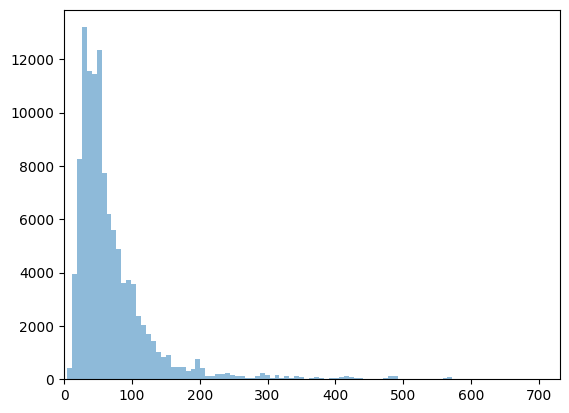

In [6]:
import numpy as np
import math
from matplotlib import pyplot as plt
data = sequence_lengths
bins = np.linspace(math.ceil(min(data)), 
                   math.floor(max(data)),
                   100) # fixed number of bins

plt.xlim([min(data)-5, max(data)+5])

plt.hist(data, bins=bins, alpha=0.5)

(array([1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 5.780e+02,
        0.000e+00, 0.000e+00, 0.000e+00, 1.981e+03, 0.000e+00, 0.000e+00,
        0.000e+00, 7.030e+02, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        2.990e+02, 0.000e+00, 0.000e+00, 0.000e+00, 8.430e+02, 0.000e+00,
        0.000e+00, 0.000e+00, 1.725e+03, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 1.406e+03, 0.000e+00, 0.000e+00, 0.000e+00, 2.094e+03,
        0.000e+00, 0.000e+00, 0.000e+00, 3.439e+03, 0.000e+00, 0.000e+00,
        0.000e+00, 2.629e+03, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        3.666e+03, 0.000e+00, 0.000e+00, 0.000e+00, 6.090e+03, 0.000e+00,
        0.000e+00, 0.000e+00, 7.927e+03, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 3.881e+03, 0.000e+00, 0.000e+00, 0.000e+00, 7.705e+03,
        0.000e+00, 0.000e+00, 0.000e+0

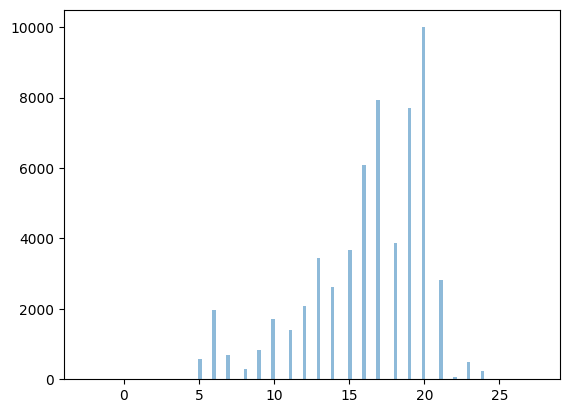

In [ ]:
import numpy as np
import math
from matplotlib import pyplot as plt

data = feature_mask.drop('op_id', axis=1).sum(axis=1).values

bins = np.linspace(math.ceil(min(data)), 
                   math.floor(max(data)),
                   100) # fixed number of bins

plt.xlim([min(data)-5, max(data)+5])

plt.hist(data, bins=bins, alpha=0.5)

In [ ]:
#unnecessary batching given i delete everything above 200 timesteps
tensors = []
for op_id, group in tqdm(df.groupby("op_id"), desc="grouping by op_ids"):
    mat = torch.tensor(group.drop(columns=['op_id', 'chart_time']).values)
    if mat.shape[0] < 200: # throws away about 4% of longest operations lol
        tensors.append(mat)
        if group.iloc[0]['aki'] >= 0.3:
            tensors.extend([mat] * 20)
# sorted_tensors = sorted(tensors, key=lambda x: x.shape[0])
sorted_tensors = tensors.copy()
random.shuffle(sorted_tensors)
sequence_lengths = [tensor.shape[0] for tensor in sorted_tensors]

batch_size = 5000
num_batches = int(np.ceil(len(sorted_tensors) / batch_size))
batched_X = []
batched_y = []
batched_seq_len = []


for i in tqdm(range(num_batches), desc="batching and zero padding data"):

    batch_list = []
    ending_idx = min((i + 1) * batch_size, len(sorted_tensors))
    # pad_length = sequence_lengths[ending_idx - 1] # only works when sorted increasingly
    pad_length = max(sequence_lengths[i * batch_size : ending_idx - 1])
    for tensor in sorted_tensors[i * batch_size : ending_idx]:
        if pad_length < tensor.shape[0]:
            print("error")
        batch_list.append(torch.nn.functional.pad(tensor, pad=(0, 0, 0, pad_length - tensor.shape[0]), value=0))
    batch = torch.stack(batch_list).float()
    batched_X.append(batch[:, :, :-1].to(device))
    batched_y.append(batch[:, 0, -1].unsqueeze(1).to(device))
    batched_seq_len.append(sequence_lengths[i * batch_size : ending_idx])


In [ ]:
base? with randomized 
0%|          | 1/1000 [00:01<21:04,  1.27s/it]Epoch: 0, loss: 0.43542
  1%|          | 11/1000 [00:09<14:34,  1.13it/s]Epoch: 10, loss: 0.40127
  2%|▏         | 21/1000 [00:18<14:17,  1.14it/s]Epoch: 20, loss: 0.38730
  3%|▎         | 31/1000 [00:27<13:35,  1.19it/s]Epoch: 30, loss: 0.37480
  4%|▍         | 41/1000 [00:35<13:50,  1.15it/s]Epoch: 40, loss: 0.36644
  5%|▌         | 51/1000 [00:44<13:27,  1.18it/s]Epoch: 50, loss: 0.36204
  6%|▌         | 61/1000 [00:52<13:25,  1.17it/s]Epoch: 60, loss: 0.35856
  7%|▋         | 71/1000 [01:01<13:36,  1.14it/s]Epoch: 70, loss: 0.35698
  8%|▊         | 81/1000 [01:10<13:19,  1.15it/s]Epoch: 80, loss: 0.35459
  9%|▉         | 91/1000 [01:19<13:07,  1.15it/s]Epoch: 90, loss: 0.35319
 10%|█         | 101/1000 [01:27<13:06,  1.14it/s]Epoch: 100, loss: 0.35243
 11%|█         | 111/1000 [01:36<13:05,  1.13it/s]Epoch: 110, loss: 0.35185
 12%|█▏        | 121/1000 [01:45<12:40,  1.16it/s]Epoch: 120, loss: 0.35269
 13%|█▎        | 131/1000 [01:54<12:43,  1.14it/s]Epoch: 130, loss: 0.35130
 14%|█▍        | 141/1000 [02:02<12:37,  1.13it/s]Epoch: 140, loss: 0.35064
 15%|█▌        | 151/1000 [02:11<12:21,  1.14it/s]Epoch: 150, loss: 0.35040
 16%|█▌        | 161/1000 [02:20<12:19,  1.14it/s]Epoch: 160, loss: 0.34996
 17%|█▋        | 171/1000 [02:29<12:04,  1.14it/s]Epoch: 170, loss: 0.34933
 18%|█▊        | 181/1000 [02:37<11:37,  1.17it/s]Epoch: 180, loss: 0.34958
 19%|█▉        | 191/1000 [02:46<11:17,  1.19it/s]Epoch: 190, loss: 0.34978
 20%|██        | 201/1000 [02:54<11:39,  1.14it/s]Epoch: 200, loss: 0.35220
 21%|██        | 211/1000 [03:03<11:37,  1.13it/s]Epoch: 210, loss: 0.35119
 22%|██▏       | 221/1000 [03:12<11:33,  1.12it/s]Epoch: 220, loss: 0.35057
 23%|██▎       | 231/1000 [03:21<11:14,  1.14it/s]Epoch: 230, loss: 0.35016
 24%|██▍       | 241/1000 [03:30<11:09,  1.13it/s]Epoch: 240, loss: 0.35046
 25%|██▌       | 251/1000 [03:38<10:59,  1.14it/s]Epoch: 250, loss: 0.35079
 26%|██▌       | 261/1000 [03:47<10:51,  1.13it/s]Epoch: 260, loss: 0.34958
 27%|██▋       | 271/1000 [03:56<10:43,  1.13it/s]Epoch: 270, loss: 0.34962
 28%|██▊       | 281/1000 [04:05<10:32,  1.14it/s]Epoch: 280, loss: 0.34940
 29%|██▉       | 291/1000 [04:13<08:55,  1.33it/s]Epoch: 290, loss: 0.34881
 30%|███       | 301/1000 [04:21<10:16,  1.13it/s]Epoch: 300, loss: 0.35151
 31%|███       | 311/1000 [04:30<10:12,  1.12it/s]Epoch: 310, loss: 0.35135
 32%|███▏      | 321/1000 [04:39<09:58,  1.14it/s]Epoch: 320, loss: 0.35125
 33%|███▎      | 331/1000 [04:48<09:52,  1.13it/s]Epoch: 330, loss: 0.35122
 34%|███▍      | 341/1000 [04:57<09:38,  1.14it/s]Epoch: 340, loss: 0.35081
 35%|███▌      | 351/1000 [05:06<09:29,  1.14it/s]Epoch: 350, loss: 0.34992
 36%|███▌      | 361/1000 [05:14<08:24,  1.27it/s]Epoch: 360, loss: 0.35072
 37%|███▋      | 371/1000 [05:21<08:22,  1.25it/s]Epoch: 370, loss: 0.34935
 38%|███▊      | 381/1000 [05:30<08:49,  1.17it/s]Epoch: 380, loss: 0.34899
 39%|███▉      | 391/1000 [05:38<08:46,  1.16it/s]Epoch: 390, loss: 0.34874
 40%|████      | 401/1000 [05:47<08:39,  1.15it/s]Epoch: 400, loss: 0.34850
 41%|████      | 411/1000 [05:55<08:14,  1.19it/s]Epoch: 410, loss: 0.34834
 42%|████▏     | 421/1000 [06:04<08:22,  1.15it/s]Epoch: 420, loss: 0.34801
 43%|████▎     | 431/1000 [06:13<07:52,  1.21it/s]Epoch: 430, loss: 0.34811
 44%|████▍     | 441/1000 [06:21<08:01,  1.16it/s]Epoch: 440, loss: 0.34801
 45%|████▌     | 451/1000 [06:30<07:52,  1.16it/s]Epoch: 450, loss: 0.34783
 46%|████▌     | 461/1000 [06:38<07:48,  1.15it/s]Epoch: 460, loss: 0.34723
 47%|████▋     | 471/1000 [06:47<07:40,  1.15it/s]Epoch: 470, loss: 0.34708
 48%|████▊     | 481/1000 [06:55<07:25,  1.17it/s]Epoch: 480, loss: 0.35465
 49%|████▉     | 491/1000 [07:04<07:30,  1.13it/s]Epoch: 490, loss: 0.35335
 50%|█████     | 501/1000 [07:13<07:15,  1.15it/s]Epoch: 500, loss: 0.35257
 51%|█████     | 511/1000 [07:22<07:13,  1.13it/s]Epoch: 510, loss: 0.35227
 52%|█████▏    | 521/1000 [07:31<07:04,  1.13it/s]Epoch: 520, loss: 0.35204
 53%|█████▎    | 531/1000 [07:40<06:56,  1.13it/s]Epoch: 530, loss: 0.35245
 54%|█████▍    | 541/1000 [07:48<06:45,  1.13it/s]Epoch: 540, loss: 0.35165
 55%|█████▌    | 551/1000 [07:57<06:39,  1.13it/s]Epoch: 550, loss: 0.35129
 56%|█████▌    | 561/1000 [08:06<06:27,  1.13it/s]Epoch: 560, loss: 0.35119
 57%|█████▋    | 571/1000 [08:15<06:12,  1.15it/s]Epoch: 570, loss: 0.35093
 58%|█████▊    | 581/1000 [08:23<05:53,  1.18it/s]Epoch: 580, loss: 0.35080
 59%|█████▊    | 586/1000 [08:28<05:59,  1.15it/s]

In [11]:
def performance_dict(y_binary_test, y_pred, y_prob, bool_print=False, plot=False, copy_print=False):
    print("----------")
    rtn = {}
    report = classification_report(y_binary_test, y_pred, output_dict=True)
    rtn['Precision'] = report['True']['precision']
    rtn['Sensitivity'] = report['True']['recall']
    rtn["Accuracy"] = accuracy_score(y_binary_test, y_pred)
    fpr, tpr, thresholds = roc_curve(y_binary_test, y_prob)
    rtn["rc_auc"] = auc(fpr, tpr)
    prec, rec, thresholds = precision_recall_curve(y_binary_test, y_prob)
    rtn["pr_auc"] = auc(rec, prec)
    rtn['Specificity'] = report['False']['recall']
    rtn['Negative Predictive Value'] = report['False']['precision']
    rtn['F1 Score'] = report['True']['f1-score']

    if bool_print:
        for key, value in rtn.items():
            print(f"{key}: {value:.4f}")
    if copy_print:
        for item in rtn.items():
            print(f"{item[1]:.4f}")

    if plot:
        # Plot ROC Curve
        plt.figure()
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {rtn["rc_auc"]:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve (Using Regression Output)')
        plt.legend(loc='lower right')
        plt.show()

        # Plot PR curve
        plt.figure()
        plt.plot(prec, rec, color='yellow', lw=2, label=f'PR curve (area = {rtn["pr_auc"]:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('Precision')
        plt.ylabel('Recall')
        plt.title('Precision-Recall Curve')
        plt.legend(loc='lower right')
        plt.show()
        print("----------")

    return rtn
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_curve, auc, precision_recall_curve, average_precision_score
from joblib import Parallel, delayed

import numpy as np
from sklearn.svm import SVC
from tqdm import tqdm

file = "/home/server/Projects/data/AKI/tabular_combined.npz"

# Load data
with np.load(file, allow_pickle=True) as data:
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_binary_train = data["y_binary_train"]
    y_binary_test = data["y_binary_test"]



In [3]:
batch_size = 2000
num_batches = int(np.ceil(len(X_train) / batch_size))
y_pred_sum = np.zeros(y_binary_test.shape)
y_prob_sum = np.zeros(y_binary_test.shape)

for i in tqdm(range(num_batches)):
    
    X_batch = X_train[i * batch_size : (i + 1) * batch_size]
    y_batch = y_binary_train[i * batch_size : (i + 1) * batch_size]
    svc = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
    svc.fit(X_batch, y_batch)

    y_pred_sum = y_pred_sum + svc.predict(X_test)
    y_prob_sum = y_prob_sum + svc.predict_proba(X_test)[:, 1]

  0%|          | 0/45 [00:00<?, ?it/s]

100%|██████████| 45/45 [15:13<00:00, 20.30s/it]


In [4]:
y_pred_sum

array([ 0.,  0.,  5., ...,  0.,  2., 15.])

In [17]:
((y_pred_sum / num_batches) > 0.5)[:10]

array([False, False, False,  True, False, False,  True,  True, False,
       False])

In [18]:
y_pred = (y_pred_sum / num_batches) > 0.5
y_prob = y_pred_sum / num_batches
performance_dict(y_binary_test, y_pred, y_prob, bool_print=True, plot=False, copy_print=True)

----------
Precision: 0.1799
Sensitivity: 0.7650
Accuracy: 0.7783
rc_auc: 0.8451
pr_auc: 0.4027
Specificity: 0.7791
Negative Predictive Value: 0.9813
F1 Score: 0.2913
0.1799
0.7650
0.7783
0.8451
0.4027
0.7791
0.9813
0.2913


{'Precision': 0.17991913746630728,
 'Sensitivity': 0.7650429799426934,
 'Accuracy': 0.778289810547875,
 'rc_auc': 0.8450898730622625,
 'pr_auc': 0.402729707662262,
 'Specificity': 0.7791288566243194,
 'Negative Predictive Value': 0.9812571428571428,
 'F1 Score': 0.29132569558101473}

In [10]:
y_pred = (y_prob_sum / num_batches) > 0.5
y_prob = y_prob_sum / num_batches
performance_dict(y_binary_test, y_pred, y_prob, bool_print=True, plot=False, copy_print=True)

----------
Precision: 0.1756
Sensitivity: 0.7708
Accuracy: 0.7708
rc_auc: 0.8514
pr_auc: 0.2678
Specificity: 0.7708
Negative Predictive Value: 0.9815
F1 Score: 0.2860
0.1756
0.7708
0.7708
0.8514
0.2678
0.7708
0.9815
0.2860


{'Precision': 0.17558746736292427,
 'Sensitivity': 0.7707736389684814,
 'Accuracy': 0.7707799965864482,
 'rc_auc': 0.8513767622296529,
 'pr_auc': 0.2677814487001988,
 'Specificity': 0.7707803992740472,
 'Negative Predictive Value': 0.9815114397966258,
 'F1 Score': 0.2860180754917597}

In [39]:
y_binary_test.shape

(11718,)

In [37]:
y_pred.shape

(11718,)

In [26]:
(y_prob + y_prob) / 2

array([0.20107036, 0.13549884, 0.44091971, ..., 0.09718655, 0.16044904,
       0.36368808])

In [ ]:
# -------------------- SUPPORT VECTOR CLASSIFICATION (SVC) --------------------
print("\nSVM Classification:")

# Train SVM classifier (RBF kernel works best for most cases)
svc = SVC(kernel='rbf', C=1.0, probability=True, random_state=42)
svc.fit(X_train, y_binary_train)

# Predict binary labels
y_pred = svc.predict(X_test)

y_prob = svc.predict_proba(X_test)[:, 1]

performance_dict(y_binary_test, y_pred, y_prob, bool_print=True, plot=False, copy_print=True)

In [2]:
svm_0 = SVC(kernel='rbf', probability=True, random_state=42)
svm_1 = SVC(kernel='rbf', probability=True, random_state=42)
svm_2 = SVC(kernel='rbf', probability=True, random_state=42)
svm_3 = SVC(kernel='rbf', probability=True, random_state=42)
svm_4 = SVC(kernel='rbf', probability=True, random_state=42)
svm_5 = SVC(kernel='rbf', probability=True, random_state=42)
svm_6 = SVC(kernel='rbf', probability=True, random_state=42)
svm_7 = SVC(kernel='rbf', probability=True, random_state=42)
svm_8 = SVC(kernel='rbf', probability=True, random_state=42)
svm_9 = SVC(kernel='rbf', probability=True, random_state=42)


# Voting Classifier (Soft Voting: Uses Predicted Probabilities)
ensemble = VotingClassifier(
    estimators=[
        ('svm_0', svm_0),
        ('svm_1', svm_1),
        ('svm_2', svm_2),
        ('svm_3', svm_3),
        ('svm_4', svm_4),
        ('svm_5', svm_5),
        ('svm_6', svm_6),
        ('svm_7', svm_7),
        ('svm_8', svm_8),
        ('svm_9', svm_9),
    ],
    voting='soft'  # Uses probability-based voting
)



In [ ]:

# Train Ensemble Model
ensemble.fit(X_train, y_binary_train)

In [ ]:


# Predict binary labels
y_pred = ensemble.predict(X_test)


# Predict probabilities for ROC curve
y_prob = ensemble.predict_proba(X_test)[:, 1]

NameError: name 'y_prob_sum' is not defined

In [17]:
with np.load(file, allow_pickle=True) as data:
    X_train=data["X_train"]
    X_test=data["X_test"]
    y_train=data["y_train"]
    y_test=data["y_test"]
    y_binary_train=data["y_binary_train"]
    y_binary_test=data["y_binary_test"]

architectures = [   (8, 8, 4, 32, 2),
                    (8, 16, 4, 16, 2),
                    (32, 16, 32, 2),
                    (64, 16, 16, 8)
                    ]
before = time.time()
for arch in architectures:
    print(arch)
    model = MLPClassifier(random_state=42, max_iter=1000, hidden_layer_sizes=arch)
    model.fit(X_train, y_binary_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    print(arch)
    performance_dict(y_binary_test, y_pred, y_prob, bool_print=True, plot=False, copy_print=True)
elapsed_time = time.time() - before
print(elapsed_time)

(8, 8, 4, 32, 2)
(8, 8, 4, 32, 2)
----------
Precision: 0.1982
Sensitivity: 0.4771
Accuracy: 0.8539
rc_auc: 0.6927
pr_auc: 0.1913
Specificity: 0.8778
Negative Predictive Value: 0.9636
F1 Score: 0.2801
0.1982
0.4771
0.8539
0.6927
0.1913
0.8778
0.9636
0.2801
(8, 16, 4, 16, 2)
(8, 16, 4, 16, 2)
----------
Precision: 0.1260
Sensitivity: 0.6533
Accuracy: 0.7094
rc_auc: 0.7071
pr_auc: 0.3920
Specificity: 0.7130
Negative Predictive Value: 0.9701
F1 Score: 0.2113
0.1260
0.6533
0.7094
0.7071
0.3920
0.7130
0.9701
0.2113
(32, 16, 32, 2)
(32, 16, 32, 2)
----------
Precision: 0.1770
Sensitivity: 0.3410
Accuracy: 0.8663
rc_auc: 0.7071
pr_auc: 0.2586
Specificity: 0.8995
Negative Predictive Value: 0.9557
F1 Score: 0.2330
0.1770
0.3410
0.8663
0.7071
0.2586
0.8995
0.9557
0.2330
(64, 16, 16, 8)
(64, 16, 16, 8)
----------
Precision: 0.2094
Sensitivity: 0.2693
Accuracy: 0.8959
rc_auc: 0.6993
pr_auc: 0.1562
Specificity: 0.9356
Negative Predictive Value: 0.9529
F1 Score: 0.2356
0.2094
0.2693
0.8959
0.6993
0.

In [ ]:
import numpy as np
from sklearn.svm import SVC, LinearSVC

file = "/home/server/Projects/data/AKI/tabular_combined.npz"

endpoint = 515
samp = 5000

# Load data
with np.load(file, allow_pickle=True) as data:
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_binary_train = data["y_binary_train"]
    y_binary_test = data["y_binary_test"][:samp]


In [13]:
# -------------------- SUPPORT VECTOR CLASSIFICATION (SVC) --------------------
print("\nSVM Classification:")

# Train SVM classifier (RBF kernel works best for most cases)
svc = SVC(kernel='rbf', probability=True, random_state=42)
svc.fit(X_train, y_binary_train)

# Predict binary labels
y_pred = svc.predict(X_test)

y_prob = svc.predict_proba(X_test)[:, 1]

performance_dict(y_binary_test, y_pred, y_prob, bool_print=True, plot=False, copy_print=True)


SVM Classification:
----------
Precision: 0.1887
Sensitivity: 0.7394
Accuracy: 0.8046
rc_auc: 0.8478
pr_auc: 0.2668
Specificity: 0.8085
Negative Predictive Value: 0.9810
F1 Score: 0.3006
0.1887
0.7394
0.8046
0.8478
0.2668
0.8085
0.9810
0.3006


{'Precision': 0.18867924528301888,
 'Sensitivity': 0.7394366197183099,
 'Accuracy': 0.8046,
 'rc_auc': 0.8478482749764062,
 'pr_auc': 0.26682493181206823,
 'Specificity': 0.8085241730279898,
 'Negative Predictive Value': 0.980962181631078,
 'F1 Score': 0.3006442376521117}

In [20]:
import numpy as np
import pandas as pd
from pathlib import Path
from tqdm import tqdm
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

inspire_path = Path("/home/server/Projects/data/INSPIRE/physionet.org/files/inspire/1.3")
vitals_file = inspire_path / "vitals.csv"
preop_cleaned = "/home/server/Projects/data/AKI/preop_cleaned.csv"
output_csv = '/home/server/Projects/data/AKI/time_series_cleaned.csv'

In [2]:
file = "/home/server/Projects/data/AKI/tabular_combined.npz"

with np.load(file, allow_pickle=True) as data:
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_binary_train = data["y_binary_train"]
    y_binary_test = data["y_binary_test"]

In [5]:
X_train.shape

(88160, 515)

In [6]:
X_test.shape

(11718, 515)

In [3]:
df = pd.DataFrame(np.vstack((X_test, X_train)))

In [4]:
column_variances = df.var()


In [10]:

print(column_variances.sort_values()[:20])

248        0.0
15         0.0
251        0.0
266        0.0
27     0.00001
26     0.00002
18     0.00004
29     0.00004
368    0.00023
488    0.00023
392    0.00023
320    0.00023
344    0.00023
464    0.00023
24     0.00047
307    0.00051
355    0.00051
379    0.00051
475    0.00051
451    0.00051
dtype: object


In [14]:
df.iloc[:,:270]

,0,1,2,3,4,5,6,7,8,9,...,260,261,262,263,264,265,266,267,268,269
0,-0.562517,True,0.853081,-0.251433,2.0,0.0,0.023223,-0.845158,-0.60024,0.0,...,0.070798,1.52204,0.095658,0.049682,0.07124,0.120136,-0.0,0.095304,-0.486797,-0.484914
1,-0.892939,True,0.298345,0.175574,1.0,0.0,0.252522,-0.000027,-0.679693,0.0,...,0.070798,0.043833,0.095658,0.049682,0.07124,0.120136,-0.0,0.095304,0.024309,-0.724186
2,-1.223362,False,-0.811126,0.602581,1.0,0.0,0.306284,1.427907,2.220359,0.0,...,0.070798,-0.232027,0.095658,0.049682,0.07124,0.120136,-0.0,0.095304,-0.58211,0.006266
3,-1.223362,False,-0.811126,-1.105448,2.0,0.0,-1.134736,-0.831476,1.465551,0.0,...,0.070798,-0.447245,0.095658,-2.236735,0.07124,0.120136,-0.0,0.095304,0.122042,-0.175545
4,-1.884207,False,-0.256391,-1.959462,2.0,1.0,-1.852518,-2.239178,-0.123519,1.0,...,0.070798,0.043833,0.095658,-1.573433,0.07124,0.120136,-0.0,0.095304,0.744956,-1.316241
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99873,0.098328,True,0.298345,-1.105448,2.0,0.0,-0.884987,-1.49539,-0.441333,0.0,...,0.070798,-0.136136,0.095658,0.089107,0.07124,0.120136,-0.0,0.095304,0.024309,-0.761786
99874,-0.562517,False,-1.365862,0.602581,2.0,0.0,0.154954,1.963883,1.783365,0.0,...,0.070798,-0.462006,0.095658,0.049682,0.07124,0.120136,-0.0,-1.890545,-0.610645,0.622979
99875,-0.892939,True,0.853081,1.456595,2.0,0.0,1.419102,1.033101,-0.004338,0.0,...,0.070798,-1.006172,0.095658,0.049682,0.07124,0.120136,-0.0,0.095304,-1.051673,-1.118985
99876,1.089596,True,0.853081,1.029588,2.0,0.0,1.088256,0.563537,0.035388,1.0,...,0.070798,0.043833,0.095658,0.049682,0.07124,0.120136,-0.0,0.095304,-0.721019,-0.666611


In [23]:
pca = PCA()
pca.fit(df)

PCA()

In [24]:
tot = 0
sofar = []
for decimal in pca.explained_variance_ratio_:
    tot += decimal
    sofar.append(tot)

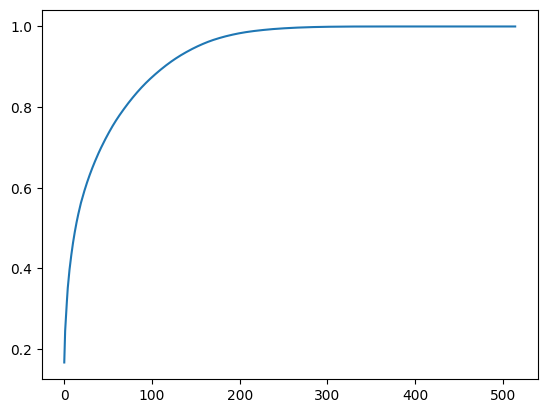

In [25]:
plt.plot(sofar)

In [93]:
def filter_df(df, item_name=0, op_id=0):
    rtn = df.copy()
    if item_name:
        rtn = rtn.loc[rtn['item_name'] == item_name]
    if op_id:
        rtn = rtn.loc[rtn['op_id'] == op_id]
    return rtn

def format_string(input_string):
    words = input_string.split()
    formatted = ', '.join(f'"{word}"' for word in words)
    return formatted

In [ ]:
# set up time series data loader to filter to the ones we want for high and medium frequency

In [42]:
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.stats import entropy, kurtosis, skew

inspire_path = Path("/home/server/Projects/data/INSPIRE/physionet.org/files/inspire/1.3")
vitals_file = inspire_path / "vitals.csv"
preop_cleaned = "/home/server/Projects/data/AKI/preop_cleaned.csv"
output_file = '/home/server/Projects/data/AKI/feature_engineered.csv'


# Load data from CSVs
print(f"Loading Data")
df_vitals = pd.read_csv(vitals_file)
df_preop = pd.read_csv(preop_cleaned)

# Cut down df_vitals to only include op_ids included in df_preop
df_vitals = df_vitals[df_vitals['op_id'].isin(df_preop['op_id'].unique())]

Loading Data
